In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from pykalman import KalmanFilter

Trace statistics:
[39.99241732 22.726353    9.92615351  1.86981556]

Critical values (90%, 95%, 99%):
[[44.4929 47.8545 54.6815]
 [27.0669 29.7961 35.4628]
 [13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]

Eigenvectors:
[[  7.28095618 -14.89533184  -3.86242718  -3.65100343]
 [  7.32432372   7.97817923  11.16320403   2.4779837 ]
 [ -7.33334303   9.64617104  -0.50209008  -0.09612584]
 [ -7.7141551   -3.02033025   4.05916223   2.3416576 ]]

Normalized first cointegrating vector:
[ 0.99407897  1.         -1.00123142 -1.05322422]

Estimated intercept alpha_joh_4: 1.303271320150251

ADF statistic on training spread: -3.9254141726366703
p-value: 0.0018555731157975756
Critical values: {'1%': np.float64(-3.4332013179632686), '5%': np.float64(-2.862799647940788), '10%': np.float64(-2.5674405676968886)}


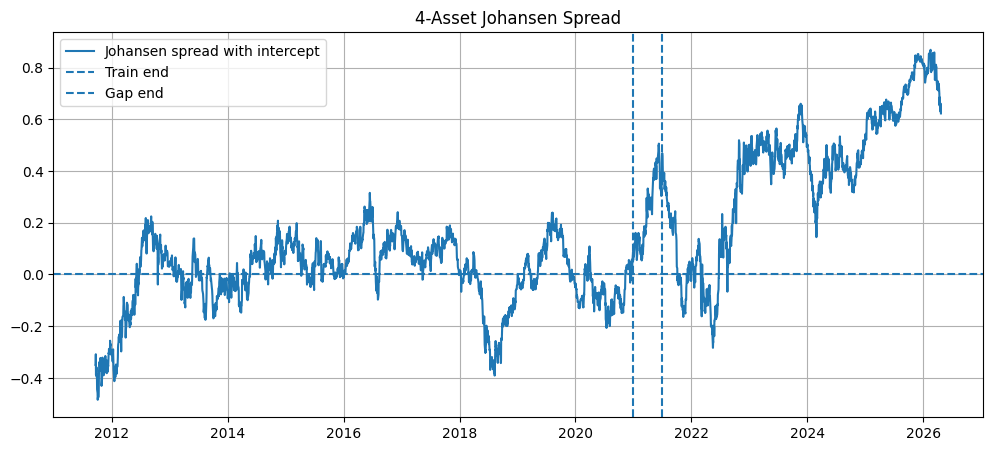

In [31]:


# -----------------------------
# 1. Load and prepare data
# -----------------------------
df1 = pd.read_csv(
    r'C:\Users\Antonio\Documents\GitHub\Spring2026-TIC\Ensemble_Wiktor\data\merged_corn_soybean_wheat_cotton.csv',
    skiprows=[1],
    index_col=0,
    parse_dates=True
)

corn = df1['close_corn']
soybean = df1['close_soybean']
wheat = df1['close_wheat']
cotton = df1['close_cotton']

df = pd.concat([corn, soybean, wheat, cotton], axis=1)
df.columns = ['Corn', 'Soybean', 'Wheat', 'Cotton']
df = df.dropna().copy()

prices = df.reset_index().rename(columns={df.index.name if df.index.name else 'index': 'Date'})

# -----------------------------
# 2. Log prices
# -----------------------------
prices["log_corn"] = np.log(prices["Corn"])
prices["log_soybean"] = np.log(prices["Soybean"])
prices["log_wheat"] = np.log(prices["Wheat"])
prices["log_cotton"] = np.log(prices["Cotton"])

# -----------------------------
# 3. Train / test split
# -----------------------------
train_end = "2020-12-31"
gap_end   = "2021-06-30"

train = prices[prices["Date"] <= train_end].copy()
test  = prices[prices["Date"] > gap_end].copy()

# -----------------------------
# 4. Johansen test on training set
# -----------------------------
joh_data = train[["log_corn", "log_soybean", "log_wheat", "log_cotton"]].dropna()

jres = coint_johansen(joh_data, det_order=0, k_ar_diff=1)

print("Trace statistics:")
print(jres.lr1)
print("\nCritical values (90%, 95%, 99%):")
print(jres.cvt)

print("\nEigenvectors:")
print(jres.evec)

# -----------------------------
# 5. First cointegrating vector
# -----------------------------
vec = jres.evec[:, 0]

# normalize on soybean
vec = vec / vec[1]

print("\nNormalized first cointegrating vector:")
print(vec)

# -----------------------------
# 6. Estimate intercept on training set
# -----------------------------
alpha_joh_4 = (
    vec[0] * train["log_corn"] +
    vec[1] * train["log_soybean"] +
    vec[2] * train["log_wheat"] +
    vec[3] * train["log_cotton"]
).mean()

print("\nEstimated intercept alpha_joh_4:", alpha_joh_4)

# -----------------------------
# 7. Construct spread with intercept
# -----------------------------
prices["spread_joh_4"] = (
    vec[0] * prices["log_corn"] +
    vec[1] * prices["log_soybean"] +
    vec[2] * prices["log_wheat"] +
    vec[3] * prices["log_cotton"] -
    alpha_joh_4
)

train["spread_joh_4"] = (
    vec[0] * train["log_corn"] +
    vec[1] * train["log_soybean"] +
    vec[2] * train["log_wheat"] +
    vec[3] * train["log_cotton"] -
    alpha_joh_4
)

test["spread_joh_4"] = (
    vec[0] * test["log_corn"] +
    vec[1] * test["log_soybean"] +
    vec[2] * test["log_wheat"] +
    vec[3] * test["log_cotton"] -
    alpha_joh_4
)

# -----------------------------
# 8. Check stationarity of spread
# -----------------------------
adf_res = adfuller(train["spread_joh_4"].dropna())

print("\nADF statistic on training spread:", adf_res[0])
print("p-value:", adf_res[1])
print("Critical values:", adf_res[4])

# -----------------------------
# 9. Plot spread
# -----------------------------
plt.figure(figsize=(12, 5))
plt.plot(prices["Date"], prices["spread_joh_4"], label="Johansen spread with intercept")
plt.axhline(0, linestyle="--")
plt.axvline(pd.to_datetime(train_end), linestyle="--", label="Train end")
plt.axvline(pd.to_datetime(gap_end), linestyle="--", label="Gap end")
plt.title("4-Asset Johansen Spread")
plt.legend()
plt.grid(True)
plt.show()

In [32]:
print(df.head(5))

                 Corn    Soybean       Wheat  Cotton
date                                                
2011-09-20  45.540001  25.080000  124.349998    3.23
2011-09-21  44.799999  24.340000  121.150002    3.16
2011-09-22  42.990002  24.000000  115.000000    3.04
2011-09-23  42.450001  23.000000  117.800003    3.04
2011-09-26  43.209999  23.459999  117.949997    3.06


In [33]:
print(prices[["Date"]].head())
print(prices[["Date"]].tail())

        Date
0 2011-09-20
1 2011-09-21
2 2011-09-22
3 2011-09-23
4 2011-09-26
           Date
3598 2026-04-17
3599 2026-04-20
3600 2026-04-21
3601 2026-04-22
3602 2026-04-23


Computing half-life:

In [34]:
# use training spread only
spread = train["spread_joh_4"].dropna().copy()

# construct lagged spread and spread change
spread_lag = spread.shift(1)
spread_diff = spread - spread_lag

hl_df = pd.concat([spread_diff, spread_lag], axis=1).dropna()
hl_df.columns = ["spread_diff", "spread_lag"]

# regression: Δs_t = lambda * s_{t-1} + error
X = hl_df["spread_lag"]
X = sm.add_constant(X)
model = sm.OLS(hl_df["spread_diff"], X).fit()

lambda_hat = model.params["spread_lag"]

half_life = -np.log(2) / lambda_hat if lambda_hat < 0 else np.nan

print("lambda_hat:", lambda_hat)
print("half-life:", half_life)
print(model.summary())

lambda_hat: -0.013997469544628742
half-life: 49.51946338228878
                            OLS Regression Results                            
Dep. Variable:            spread_diff   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     17.91
Date:                Thu, 21 May 2026   Prob (F-statistic):           2.40e-05
Time:                        19:08:26   Log-Likelihood:                 5536.8
No. Observations:                2297   AIC:                        -1.107e+04
Df Residuals:                    2295   BIC:                        -1.106e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

In [35]:
# choose rolling window from half-life
window_z = max(2, int(round(half_life)))

# rolling mean and std, shifted by 1 to avoid look-ahead bias
prices["spread_joh_4_mean"] = prices["spread_joh_4"].rolling(window_z).mean().shift(1)
prices["spread_joh_4_std"]  = prices["spread_joh_4"].rolling(window_z).std().shift(1)

# z-score
prices["zscore_joh_4"] = (
    (prices["spread_joh_4"] - prices["spread_joh_4_mean"]) / prices["spread_joh_4_std"]
)

# avoid division by zero
prices.loc[prices["spread_joh_4_std"] == 0, "zscore_joh_4"] = np.nan

# rebuild train and test with the new columns
train = prices[prices["Date"] <= train_end].copy()
test  = prices[prices["Date"] > gap_end].copy()

print("Rolling window used for z-score:", window_z)
print(prices[["Date", "spread_joh_4", "spread_joh_4_mean", "spread_joh_4_std", "zscore_joh_4"]].head(10))

Rolling window used for z-score: 50
        Date  spread_joh_4  spread_joh_4_mean  spread_joh_4_std  zscore_joh_4
0 2011-09-20     -0.349146                NaN               NaN           NaN
1 2011-09-21     -0.346202                NaN               NaN           NaN
2 2011-09-22     -0.308329                NaN               NaN           NaN
3 2011-09-23     -0.387540                NaN               NaN           NaN
4 2011-09-26     -0.358278                NaN               NaN           NaN
5 2011-09-27     -0.366923                NaN               NaN           NaN
6 2011-09-28     -0.396312                NaN               NaN           NaN
7 2011-09-29     -0.385916                NaN               NaN           NaN
8 2011-09-30     -0.443999                NaN               NaN           NaN
9 2011-10-03     -0.457833                NaN               NaN           NaN


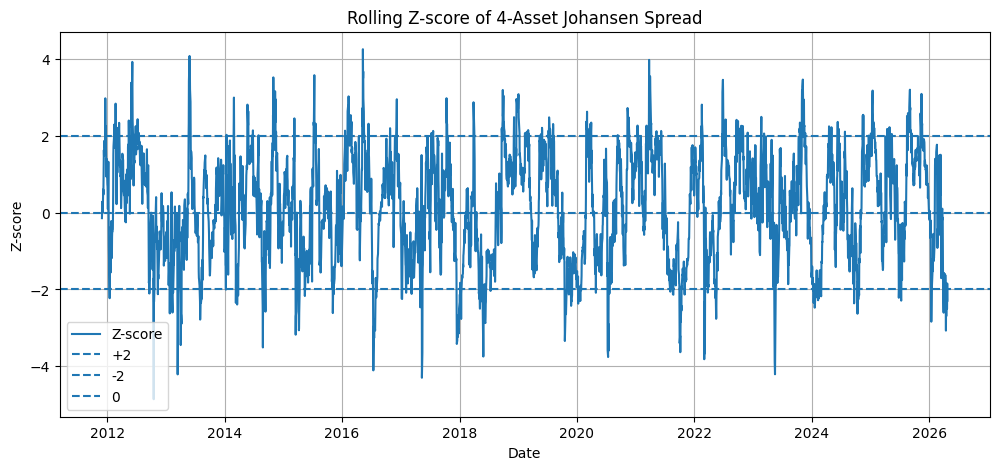

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(prices["Date"], prices["zscore_joh_4"], label="Z-score")
plt.axhline(2, linestyle="--", label="+2")
plt.axhline(-2, linestyle="--", label="-2")
plt.axhline(0, linestyle="--", label="0")
plt.title("Rolling Z-score of 4-Asset Johansen Spread")
plt.xlabel("Date")
plt.ylabel("Z-score")
plt.legend()
plt.grid(True)
plt.show()

Static beta strategy

Train stats:
{'mean_daily_ret': np.float64(0.00018906291797431759), 'std_daily_ret': np.float64(0.0052031241913678035), 'sharpe': np.float64(0.5768228218739686), 'cum_ret': np.float64(0.49663807061891974), 'max_drawdown': np.float64(-0.20701662911282004)}

Test stats:
{'mean_daily_ret': np.float64(0.00016808405599557378), 'std_daily_ret': np.float64(0.0054812569183456845), 'sharpe': np.float64(0.4867955851851173), 'cum_ret': np.float64(0.19847220299374468), 'max_drawdown': np.float64(-0.13524421613230564)}


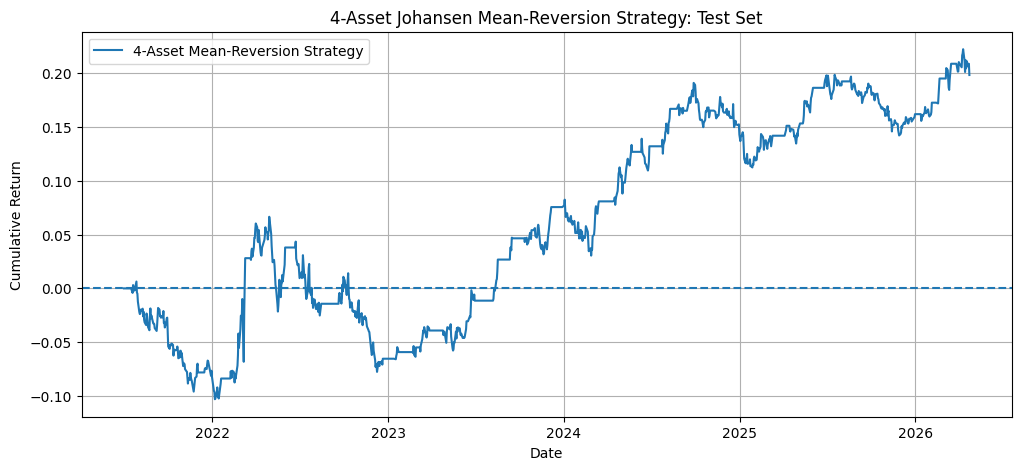

In [37]:

# ---------------------------------
# 1. choose entry / exit thresholds
# ---------------------------------
entry_z = 1.5
exit_z = 0

# ---------------------------------
# 2. generate positions from z-score
# ---------------------------------
positions = []
pos = 0

for z in prices["zscore_joh_4"]:
    if np.isnan(z):
        positions.append(0)
        continue

    if pos == 0:
        if z < -entry_z:
            pos = 1      # long spread
        elif z > entry_z:
            pos = -1     # short spread

    elif pos == 1:
        if z >= -exit_z:
            pos = 0

    elif pos == -1:
        if z <= exit_z:
            pos = 0

    positions.append(pos)

prices["position_joh_4"] = positions

# ---------------------------------
# 3. price changes in levels
# ---------------------------------
prices["d_corn"] = prices["Corn"].diff()
prices["d_soybean"] = prices["Soybean"].diff()
prices["d_wheat"] = prices["Wheat"].diff()
prices["d_cotton"] = prices["Cotton"].diff()

# ---------------------------------
# 4. portfolio pnl using yesterday's weights
# ---------------------------------
# vec is your normalized Johansen vector
# spread = vec[0]*log_corn + vec[1]*log_soybean + vec[2]*log_wheat + vec[3]*log_cotton - alpha

prices["spread_pnl_joh_4"] = (
    vec[0] * prices["d_corn"]
    + vec[1] * prices["d_soybean"]
    + vec[2] * prices["d_wheat"]
    + vec[3] * prices["d_cotton"]
)

prices["strategy_pnl_joh_4"] = (
    prices["position_joh_4"].shift(1) * prices["spread_pnl_joh_4"]
)

# ---------------------------------
# 5. capital base for normalization
# ---------------------------------
prices["capital_base_joh_4"] = (
    abs(vec[0]) * prices["Corn"].shift(1)
    + abs(vec[1]) * prices["Soybean"].shift(1)
    + abs(vec[2]) * prices["Wheat"].shift(1)
    + abs(vec[3]) * prices["Cotton"].shift(1)
)

prices["strategy_ret_joh_4"] = (
    prices["strategy_pnl_joh_4"] / prices["capital_base_joh_4"]
)

# ---------------------------------
# 6. rebuild train / test
# ---------------------------------
train = prices[prices["Date"] <= train_end].copy()
test  = prices[prices["Date"] > gap_end].copy()

# ---------------------------------
# 7. performance summary
# ---------------------------------
def strategy_stats(df, ret_col):
    ret = df[ret_col].dropna()

    mean_ret = ret.mean()
    std_ret = ret.std()
    sharpe = np.sqrt(252) * mean_ret / std_ret if std_ret > 0 else np.nan
    cum_ret = (1 + ret).prod() - 1

    equity = (1 + ret).cumprod()
    drawdown = equity / equity.cummax() - 1
    max_drawdown = drawdown.min()

    return {
        "mean_daily_ret": mean_ret,
        "std_daily_ret": std_ret,
        "sharpe": sharpe,
        "cum_ret": cum_ret,
        "max_drawdown": max_drawdown
    }

train_stats = strategy_stats(train, "strategy_ret_joh_4")
test_stats = strategy_stats(test, "strategy_ret_joh_4")

print("Train stats:")
print(train_stats)

print("\nTest stats:")
print(test_stats)

# ---------------------------------
# 8. cumulative return plot
# ---------------------------------
test["cum_ret_joh_4"] = (1 + test["strategy_ret_joh_4"].fillna(0)).cumprod() - 1

plt.figure(figsize=(12,5))
plt.plot(test["Date"], test["cum_ret_joh_4"], label="4-Asset Mean-Reversion Strategy")
plt.axhline(0, linestyle="--")
plt.title("4-Asset Johansen Mean-Reversion Strategy: Test Set")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.show()

In [38]:

# -------------------------------------------------
# 1. rolling Johansen spread for 4 assets
# -------------------------------------------------
def rolling_johansen_spread_4(df, window, det_order=0, k_ar_diff=1):
    out = df.copy()

    b_corn = np.full(len(out), np.nan)
    b_soy = np.full(len(out), np.nan)
    b_wheat = np.full(len(out), np.nan)
    b_cotton = np.full(len(out), np.nan)
    alpha_roll = np.full(len(out), np.nan)

    for t in range(window, len(out)):
        sample = out.iloc[t-window:t][
            ["log_corn", "log_soybean", "log_wheat", "log_cotton"]
        ].dropna()

        if len(sample) < window:
            continue

        try:
            jres = coint_johansen(sample, det_order=det_order, k_ar_diff=k_ar_diff)

            vec = jres.evec[:, 0]

            # normalize on soybean
            vec = vec / vec[1]

            b_corn[t] = vec[0]
            b_soy[t] = vec[1]
            b_wheat[t] = vec[2]
            b_cotton[t] = vec[3]

            alpha_roll[t] = (
                vec[0] * sample["log_corn"]
                + vec[1] * sample["log_soybean"]
                + vec[2] * sample["log_wheat"]
                + vec[3] * sample["log_cotton"]
            ).mean()

        except Exception:
            continue

    out["beta_corn_roll"] = b_corn
    out["beta_soy_roll"] = b_soy
    out["beta_wheat_roll"] = b_wheat
    out["beta_cotton_roll"] = b_cotton
    out["alpha_roll_joh_4"] = alpha_roll

    out["spread_roll_joh_4"] = (
        out["beta_corn_roll"] * out["log_corn"]
        + out["beta_soy_roll"] * out["log_soybean"]
        + out["beta_wheat_roll"] * out["log_wheat"]
        + out["beta_cotton_roll"] * out["log_cotton"]
        - out["alpha_roll_joh_4"]
    )

    return out

In [39]:
# -------------------------------------------------
# 2. rolling strategy from rolling spread
# -------------------------------------------------
def rolling_johansen_strategy_4(df, z_window, entry_z=1.5, exit_z=0):
    out = df.copy()

    z_window = max(2, int(round(z_window)))

    # rolling mean/std of spread, shifted to avoid look-ahead bias
    out["spread_roll_joh_4_mean"] = out["spread_roll_joh_4"].rolling(z_window).mean().shift(1)
    out["spread_roll_joh_4_std"] = out["spread_roll_joh_4"].rolling(z_window).std().shift(1)

    out["zscore_roll_joh_4"] = (
        (out["spread_roll_joh_4"] - out["spread_roll_joh_4_mean"]) / out["spread_roll_joh_4_std"]
    )
    out.loc[out["spread_roll_joh_4_std"] == 0, "zscore_roll_joh_4"] = np.nan

    positions = []
    pos = 0

    for z in out["zscore_roll_joh_4"]:
        if np.isnan(z):
            positions.append(0)
            continue

        if pos == 0:
            if z < -entry_z:
                pos = 1      # long spread
            elif z > entry_z:
                pos = -1     # short spread

        elif pos == 1:
            if z >= -exit_z:
                pos = 0

        elif pos == -1:
            if z <= exit_z:
                pos = 0

        positions.append(pos)

    out["position_roll_joh_4"] = positions

    # price changes
    out["d_corn"] = out["Corn"].diff()
    out["d_soybean"] = out["Soybean"].diff()
    out["d_wheat"] = out["Wheat"].diff()
    out["d_cotton"] = out["Cotton"].diff()

    # pnl uses yesterday's rolling coefficients
    out["spread_pnl_roll_joh_4"] = (
        out["beta_corn_roll"].shift(1) * out["d_corn"]
        + out["beta_soy_roll"].shift(1) * out["d_soybean"]
        + out["beta_wheat_roll"].shift(1) * out["d_wheat"]
        + out["beta_cotton_roll"].shift(1) * out["d_cotton"]
    )

    out["strategy_pnl_roll_joh_4"] = (
        out["position_roll_joh_4"].shift(1) * out["spread_pnl_roll_joh_4"]
    )

    out["capital_base_roll_joh_4"] = (
        out["beta_corn_roll"].shift(1).abs() * out["Corn"].shift(1)
        + out["beta_soy_roll"].shift(1).abs() * out["Soybean"].shift(1)
        + out["beta_wheat_roll"].shift(1).abs() * out["Wheat"].shift(1)
        + out["beta_cotton_roll"].shift(1).abs() * out["Cotton"].shift(1)
    )

    out["strategy_ret_roll_joh_4"] = (
        out["strategy_pnl_roll_joh_4"] / out["capital_base_roll_joh_4"]
    )

    return out

In [40]:
def strategy_stats(df, ret_col):
    ret = df[ret_col].dropna()

    mean_ret = ret.mean()
    std_ret = ret.std()
    sharpe = np.sqrt(252) * mean_ret / std_ret if std_ret > 0 else np.nan
    cum_ret = (1 + ret).prod() - 1

    equity = (1 + ret).cumprod()
    drawdown = equity / equity.cummax() - 1
    max_drawdown = drawdown.min()

    return {
        "mean_daily_ret": mean_ret,
        "std_daily_ret": std_ret,
        "sharpe": sharpe,
        "cum_ret": cum_ret,
        "max_drawdown": max_drawdown
    }

In [41]:
z_window = 50
window_grid = [50, 63, 98, 126, 189, 252]
results = []

for window in window_grid:
    train_roll = rolling_johansen_spread_4(train, window=window, det_order=0, k_ar_diff=1)
    train_roll = rolling_johansen_strategy_4(train_roll, z_window=z_window, entry_z=1.5, exit_z=0)

    stats = strategy_stats(train_roll, ret_col="strategy_ret_roll_joh_4")
    stats["window"] = window
    results.append(stats)

results_df = pd.DataFrame(results).sort_values("sharpe", ascending=False)
print(results_df)

   mean_daily_ret  std_daily_ret    sharpe   cum_ret  max_drawdown  window
3        0.000142       0.003536  0.635782  0.341665     -0.061692     126
2        0.000058       0.003155  0.289630  0.122632     -0.107998      98
5        0.000055       0.003999  0.217283  0.100304     -0.124918     252
1        0.000021       0.003310  0.100978  0.035367     -0.126406      63
4       -0.000029       0.004031 -0.112506 -0.074439     -0.290506     189
0       -0.000107       0.003140 -0.539907 -0.222090     -0.243707      50


In [42]:
best_window = int(results_df.iloc[5]["window"])
print("Best rolling estimation window:", best_window)

Best rolling estimation window: 50


In [43]:
prices_roll_4 = rolling_johansen_spread_4(prices, window=best_window, det_order=0, k_ar_diff=1)
prices_roll_4 = rolling_johansen_strategy_4(prices_roll_4, z_window=z_window, entry_z=1.5, exit_z=0)

train_roll_4 = prices_roll_4[prices_roll_4["Date"] <= train_end].copy()
test_roll_4  = prices_roll_4[prices_roll_4["Date"] > gap_end].copy()

print("Train stats:")
print(strategy_stats(train_roll_4, "strategy_ret_roll_joh_4"))

print("\nTest stats:")
print(strategy_stats(test_roll_4, "strategy_ret_roll_joh_4"))

Train stats:
{'mean_daily_ret': np.float64(-0.00010680434871440932), 'std_daily_ret': np.float64(0.003140295823251151), 'sharpe': np.float64(-0.5399066104784903), 'cum_ret': np.float64(-0.22209040683953263), 'max_drawdown': np.float64(-0.2437072017735461)}

Test stats:
{'mean_daily_ret': np.float64(0.00018316166403783675), 'std_daily_ret': np.float64(0.0034424067221504773), 'sharpe': np.float64(0.8446419936029199), 'cum_ret': np.float64(0.23331429330180775), 'max_drawdown': np.float64(-0.056402232929706586)}


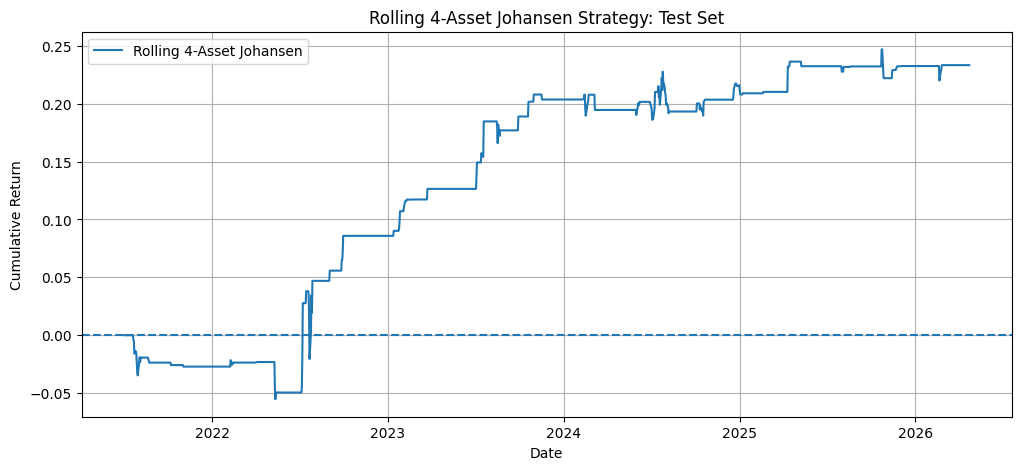

In [44]:
test_roll_4["cum_ret_roll_joh_4"] = (1 + test_roll_4["strategy_ret_roll_joh_4"].fillna(0)).cumprod() - 1

plt.figure(figsize=(12,5))
plt.plot(test_roll_4["Date"], test_roll_4["cum_ret_roll_joh_4"], label="Rolling 4-Asset Johansen")
plt.axhline(0, linestyle="--")
plt.title("Rolling 4-Asset Johansen Strategy: Test Set")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.show()

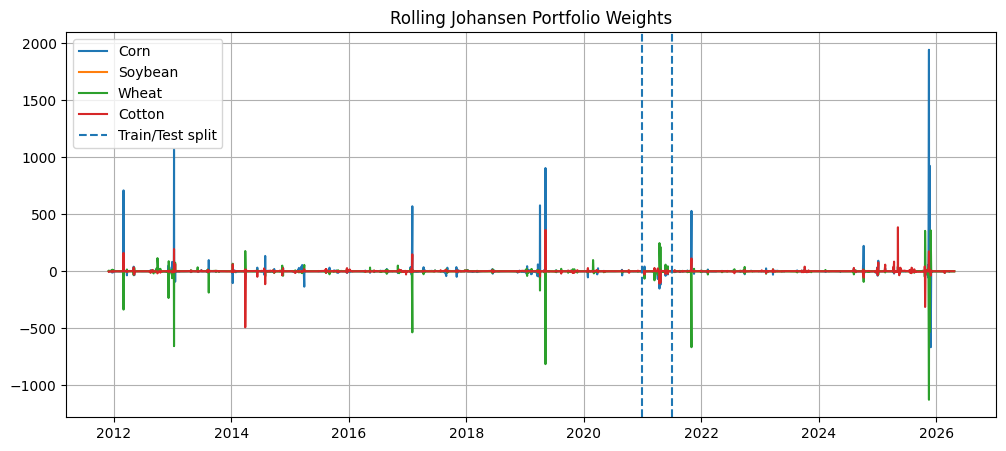

In [45]:
plt.figure(figsize=(12,5))
plt.plot(prices_roll_4["Date"], prices_roll_4["beta_corn_roll"], label="Corn")
plt.plot(prices_roll_4["Date"], prices_roll_4["beta_soy_roll"], label="Soybean")
plt.plot(prices_roll_4["Date"], prices_roll_4["beta_wheat_roll"], label="Wheat")
plt.plot(prices_roll_4["Date"], prices_roll_4["beta_cotton_roll"], label="Cotton")
plt.axvline(pd.to_datetime(train_end), linestyle="--", label="Train/Test split")
plt.axvline(pd.to_datetime(gap_end), linestyle="--")
plt.title("Rolling Johansen Portfolio Weights")
plt.legend()
plt.grid(True)
plt.show()

Kalmann strategy: build kalman spread

In [46]:


def kalman_spread_4(df, delta, alpha_init, beta_init_vec, obs_cov=0.01):
    """
    beta_init_vec should be a length-3 vector:
    [beta_corn_init, beta_wheat_init, beta_cotton_init]
    """
    y = df["log_soybean"].values

    x1 = df["log_corn"].values
    x2 = df["log_wheat"].values
    x3 = df["log_cotton"].values

    # observation matrix: [log_corn, log_wheat, log_cotton, 1]
    obs_mat = np.column_stack([x1, x2, x3, np.ones(len(df))])[:, np.newaxis, :]

    n_state = 4
    trans_cov = delta / (1 - delta) * np.eye(n_state)

    kf = KalmanFilter(
        n_dim_obs=1,
        n_dim_state=n_state,
        initial_state_mean=np.array([
            beta_init_vec[0],
            beta_init_vec[1],
            beta_init_vec[2],
            alpha_init
        ]),
        initial_state_covariance=0.1 * np.eye(n_state),
        transition_matrices=np.eye(n_state),
        observation_matrices=obs_mat,
        observation_covariance=obs_cov,
        transition_covariance=trans_cov
    )

    state_means, state_covs = kf.filter(y)

    out = df.copy()
    out["beta_corn_kf"] = state_means[:, 0]
    out["beta_wheat_kf"] = state_means[:, 1]
    out["beta_cotton_kf"] = state_means[:, 2]
    out["alpha_kf_4"] = state_means[:, 3]

    out["spread_kf_4"] = (
        out["log_soybean"]
        - out["beta_corn_kf"] * out["log_corn"]
        - out["beta_wheat_kf"] * out["log_wheat"]
        - out["beta_cotton_kf"] * out["log_cotton"]
        - out["alpha_kf_4"]
    )

    return out

Kalman strategy: build trading strategy

In [47]:
def kalman_strategy_4(df, z_window, entry_z=1.5, exit_z=0):
    out = df.copy()

    z_window = max(2, int(round(z_window)))

    out["spread_kf_4_mean"] = out["spread_kf_4"].rolling(z_window).mean().shift(1)
    out["spread_kf_4_std"] = out["spread_kf_4"].rolling(z_window).std().shift(1)

    out["zscore_kf_4"] = (
        (out["spread_kf_4"] - out["spread_kf_4_mean"]) / out["spread_kf_4_std"]
    )
    out.loc[out["spread_kf_4_std"] == 0, "zscore_kf_4"] = np.nan

    positions = []
    pos = 0

    for z in out["zscore_kf_4"]:
        if np.isnan(z):
            positions.append(0)
            continue

        if pos == 0:
            if z < -entry_z:
                pos = 1
            elif z > entry_z:
                pos = -1

        elif pos == 1:
            if z >= -exit_z:
                pos = 0

        elif pos == -1:
            if z <= exit_z:
                pos = 0

        positions.append(pos)

    out["position_kf_4"] = positions

    # price changes
    out["d_corn"] = out["Corn"].diff()
    out["d_soybean"] = out["Soybean"].diff()
    out["d_wheat"] = out["Wheat"].diff()
    out["d_cotton"] = out["Cotton"].diff()

    # pnl uses yesterday's Kalman coefficients
    out["spread_pnl_kf_4"] = (
        out["d_soybean"]
        - out["beta_corn_kf"].shift(1) * out["d_corn"]
        - out["beta_wheat_kf"].shift(1) * out["d_wheat"]
        - out["beta_cotton_kf"].shift(1) * out["d_cotton"]
    )

    out["strategy_pnl_kf_4"] = (
        out["position_kf_4"].shift(1) * out["spread_pnl_kf_4"]
    )

    out["capital_base_kf_4"] = (
        out["Soybean"].shift(1)
        + out["beta_corn_kf"].shift(1).abs() * out["Corn"].shift(1)
        + out["beta_wheat_kf"].shift(1).abs() * out["Wheat"].shift(1)
        + out["beta_cotton_kf"].shift(1).abs() * out["Cotton"].shift(1)
    )

    out["strategy_ret_kf_4"] = (
        out["strategy_pnl_kf_4"] / out["capital_base_kf_4"]
    )

    return out

In [48]:
def strategy_stats(df, ret_col):
    ret = df[ret_col].dropna()

    mean_ret = ret.mean()
    std_ret = ret.std()
    sharpe = np.sqrt(252) * mean_ret / std_ret if std_ret > 0 else np.nan
    cum_ret = (1 + ret).prod() - 1

    equity = (1 + ret).cumprod()
    drawdown = equity / equity.cummax() - 1
    max_drawdown = drawdown.min()

    return {
        "mean_daily_ret": mean_ret,
        "std_daily_ret": std_ret,
        "sharpe": sharpe,
        "cum_ret": cum_ret,
        "max_drawdown": max_drawdown
    }

beta_init_vec = np.array([
    -vec[0] / vec[1],   # corn
    -vec[2] / vec[1],   # wheat
    -vec[3] / vec[1]    # cotton
])

alpha_init = alpha_joh_4 / vec[1]

print("Initial beta vector:", beta_init_vec)
print("Initial alpha:", alpha_init)

Initial beta vector: [-0.99407897  1.00123142  1.05322422]
Initial alpha: 1.303271320150251


Grid search:

In [49]:
z_window = 50

delta_grid = [1e-7, 1e-6, 1e-5, 1e-4]
obs_grid = [0.001, 0.01, 0.1, 1.0]

results = []

for delta in delta_grid:
    for obs_cov in obs_grid:
        train_kf_4 = kalman_spread_4(
            train,
            delta=delta,
            alpha_init=alpha_init,
            beta_init_vec=beta_init_vec,
            obs_cov=obs_cov
        )

        train_kf_4 = kalman_strategy_4(
            train_kf_4,
            z_window=z_window,
            entry_z=1.5,
            exit_z=0
        )

        stats = strategy_stats(train_kf_4, ret_col="strategy_ret_kf_4")
        stats["delta"] = delta
        stats["obs_cov"] = obs_cov
        results.append(stats)

results_df = pd.DataFrame(results).sort_values("sharpe", ascending=False)
print(results_df)

    mean_daily_ret  std_daily_ret    sharpe   cum_ret  max_drawdown  \
15        0.000370       0.004732  1.241525  1.280334     -0.074692   
14        0.000274       0.004112  1.056078  0.838508     -0.056674   
10        0.000294       0.004752  0.982871  0.915190     -0.092472   
13        0.000203       0.003930  0.820047  0.566137     -0.065400   
9         0.000197       0.004182  0.746811  0.540127     -0.064603   
8         0.000140       0.003478  0.637048  0.358998     -0.072496   
11        0.000201       0.005146  0.620000  0.539201     -0.197647   
12        0.000124       0.003301  0.595616  0.312633     -0.106426   
4         0.000121       0.003861  0.499206  0.299290     -0.107928   
7         0.000156       0.005194  0.475934  0.386478     -0.186229   
5         0.000122       0.004615  0.419560  0.291420     -0.095911   
6         0.000123       0.005303  0.367213  0.283398     -0.195065   
3         0.000093       0.005142  0.287161  0.201224     -0.243437   
0     

In [50]:
best_delta = results_df.iloc[0]["delta"]
best_obs_cov = results_df.iloc[0]["obs_cov"]

print("Best delta:", best_delta)
print("Best obs_cov:", best_obs_cov)

prices_kf_4 = kalman_spread_4(
    prices,
    delta=best_delta,
    alpha_init=alpha_init,
    beta_init_vec=beta_init_vec,
    obs_cov=best_obs_cov
)

prices_kf_4 = kalman_strategy_4(
    prices_kf_4,
    z_window=z_window,
    entry_z=1.5,
    exit_z=0
)

train_kf_4 = prices_kf_4[prices_kf_4["Date"] <= train_end].copy()
test_kf_4  = prices_kf_4[prices_kf_4["Date"] > gap_end].copy()

print("Train stats:")
print(strategy_stats(train_kf_4, "strategy_ret_kf_4"))

print("\nTest stats:")
print(strategy_stats(test_kf_4, "strategy_ret_kf_4"))

Best delta: 0.0001
Best obs_cov: 1.0
Train stats:
{'mean_daily_ret': np.float64(0.000370092919123078), 'std_daily_ret': np.float64(0.004732117335405213), 'sharpe': np.float64(1.2415252073225587), 'cum_ret': np.float64(1.2803340842455824), 'max_drawdown': np.float64(-0.07469220013855749)}

Test stats:
{'mean_daily_ret': np.float64(7.576547169132396e-05), 'std_daily_ret': np.float64(0.006037486531606098), 'sharpe': np.float64(0.19921196843556868), 'cum_ret': np.float64(0.07030622423688437), 'max_drawdown': np.float64(-0.1863837687715686)}


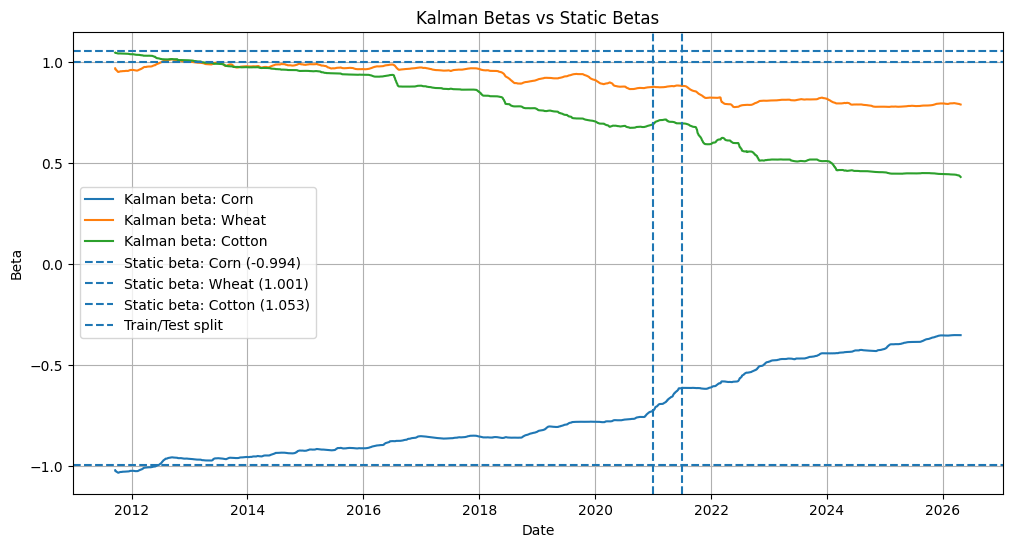

In [51]:
# static coefficients
beta_static_corn = beta_init_vec[0]
beta_static_wheat = beta_init_vec[1]
beta_static_cotton = beta_init_vec[2]

plt.figure(figsize=(12,6))

# Kalman betas
plt.plot(prices_kf_4["Date"], prices_kf_4["beta_corn_kf"], label="Kalman beta: Corn")
plt.plot(prices_kf_4["Date"], prices_kf_4["beta_wheat_kf"], label="Kalman beta: Wheat")
plt.plot(prices_kf_4["Date"], prices_kf_4["beta_cotton_kf"], label="Kalman beta: Cotton")

# Static betas
plt.axhline(beta_static_corn, linestyle="--", label=f"Static beta: Corn ({beta_static_corn:.3f})")
plt.axhline(beta_static_wheat, linestyle="--", label=f"Static beta: Wheat ({beta_static_wheat:.3f})")
plt.axhline(beta_static_cotton, linestyle="--", label=f"Static beta: Cotton ({beta_static_cotton:.3f})")

plt.axvline(pd.to_datetime(train_end), linestyle="--", label="Train/Test split")
plt.axvline(pd.to_datetime(gap_end), linestyle="--")

plt.title("Kalman Betas vs Static Betas")
plt.xlabel("Date")
plt.ylabel("Beta")
plt.legend()
plt.grid(True)
plt.show()

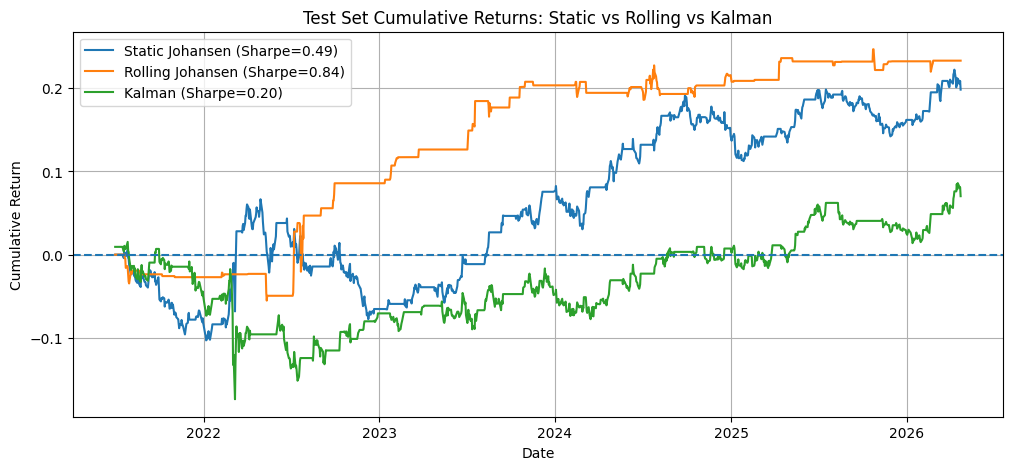

In [52]:
# test sets
test_static_4 = prices[prices["Date"] > pd.to_datetime(gap_end)].copy()
test_roll_4   = prices_roll_4[prices_roll_4["Date"] > pd.to_datetime(gap_end)].copy()
test_kf_4     = prices_kf_4[prices_kf_4["Date"] > pd.to_datetime(gap_end)].copy()

# cumulative returns
test_static_4["cum_ret_static_4"] = (1 + test_static_4["strategy_ret_joh_4"].fillna(0)).cumprod() - 1
test_roll_4["cum_ret_roll_4"]     = (1 + test_roll_4["strategy_ret_roll_joh_4"].fillna(0)).cumprod() - 1
test_kf_4["cum_ret_kf_4"]         = (1 + test_kf_4["strategy_ret_kf_4"].fillna(0)).cumprod() - 1

# Sharpe ratios
def sharpe_ratio(series):
    s = series.dropna()
    return np.sqrt(252) * s.mean() / s.std() if s.std() > 0 else np.nan

sh_static = sharpe_ratio(test_static_4["strategy_ret_joh_4"])
sh_roll   = sharpe_ratio(test_roll_4["strategy_ret_roll_joh_4"])
sh_kf     = sharpe_ratio(test_kf_4["strategy_ret_kf_4"])

plt.figure(figsize=(12,5))
plt.plot(
    test_static_4["Date"],
    test_static_4["cum_ret_static_4"],
    label=f"Static Johansen (Sharpe={sh_static:.2f})"
)
plt.plot(
    test_roll_4["Date"],
    test_roll_4["cum_ret_roll_4"],
    label=f"Rolling Johansen (Sharpe={sh_roll:.2f})"
)
plt.plot(
    test_kf_4["Date"],
    test_kf_4["cum_ret_kf_4"],
    label=f"Kalman (Sharpe={sh_kf:.2f})"
)

plt.axhline(0, linestyle="--")
plt.title("Test Set Cumulative Returns: Static vs Rolling vs Kalman")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.show()

In [53]:
def max_drawdown_from_returns(ret_series):
    equity = (1 + ret_series.fillna(0)).cumprod()
    dd = equity / equity.cummax() - 1
    return dd.min()

summary_df = pd.DataFrame({
    "strategy": ["Static Johansen", "Rolling Johansen", "Kalman"],
    "sharpe": [
        sh_static,
        sh_roll,
        sh_kf
    ],
    "final_cum_ret": [
        test_static_4["cum_ret_static_4"].iloc[-1],
        test_roll_4["cum_ret_roll_4"].iloc[-1],
        test_kf_4["cum_ret_kf_4"].iloc[-1]
    ],
    "max_drawdown": [
        max_drawdown_from_returns(test_static_4["strategy_ret_joh_4"]),
        max_drawdown_from_returns(test_roll_4["strategy_ret_roll_joh_4"]),
        max_drawdown_from_returns(test_kf_4["strategy_ret_kf_4"])
    ]
})

print(summary_df)

           strategy    sharpe  final_cum_ret  max_drawdown
0   Static Johansen  0.486796       0.198472     -0.135244
1  Rolling Johansen  0.844642       0.233314     -0.056402
2            Kalman  0.199212       0.070306     -0.186384


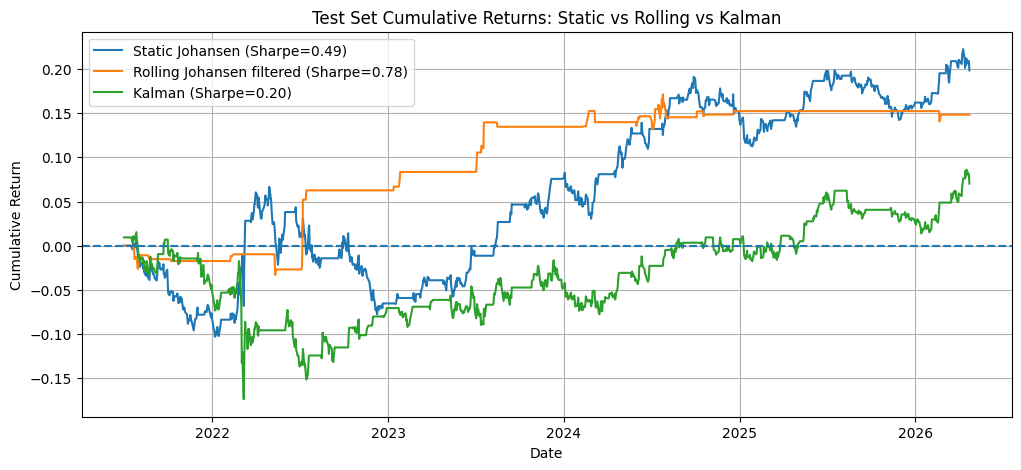

In [54]:
# test sets
test_static_4 = prices[prices["Date"] > pd.to_datetime(gap_end)].copy()
test_roll_4   = prices_roll_4[prices_roll_4["Date"] > pd.to_datetime(gap_end)].copy()
test_kf_4     = prices_kf_4[prices_kf_4["Date"] > pd.to_datetime(gap_end)].copy()

# -----------------------------
# rolling Johansen beta filter
# only trade at t if ALL betas at t-1 were within [-2, 2]
# -----------------------------
test_roll_4["betas_ok_raw"] = (
    test_roll_4["beta_corn_roll"].between(-2, 2) &
    test_roll_4["beta_soy_roll"].between(-2, 2) &
    test_roll_4["beta_wheat_roll"].between(-2, 2) &
    test_roll_4["beta_cotton_roll"].between(-2, 2)
)

# shift by 1 to avoid look-ahead bias
test_roll_4["betas_ok"] = test_roll_4["betas_ok_raw"].shift(1).fillna(False)

# filtered rolling position
test_roll_4["position_roll_joh_4_filtered"] = np.where(
    test_roll_4["betas_ok"],
    test_roll_4["position_roll_joh_4"],
    0
)

# filtered pnl and return
test_roll_4["strategy_pnl_roll_joh_4_filtered"] = (
    test_roll_4["position_roll_joh_4_filtered"].shift(1) *
    test_roll_4["spread_pnl_roll_joh_4"]
)

test_roll_4["strategy_ret_roll_joh_4_filtered"] = (
    test_roll_4["strategy_pnl_roll_joh_4_filtered"] /
    test_roll_4["capital_base_roll_joh_4"]
)

# cumulative returns
test_static_4["cum_ret_static_4"] = (1 + test_static_4["strategy_ret_joh_4"].fillna(0)).cumprod() - 1
test_roll_4["cum_ret_roll_4"]     = (1 + test_roll_4["strategy_ret_roll_joh_4_filtered"].fillna(0)).cumprod() - 1
test_kf_4["cum_ret_kf_4"]         = (1 + test_kf_4["strategy_ret_kf_4"].fillna(0)).cumprod() - 1

# Sharpe ratios
def sharpe_ratio(series):
    s = series.dropna()
    return np.sqrt(252) * s.mean() / s.std() if s.std() > 0 else np.nan

sh_static = sharpe_ratio(test_static_4["strategy_ret_joh_4"])
sh_roll   = sharpe_ratio(test_roll_4["strategy_ret_roll_joh_4_filtered"])
sh_kf     = sharpe_ratio(test_kf_4["strategy_ret_kf_4"])

plt.figure(figsize=(12,5))
plt.plot(
    test_static_4["Date"],
    test_static_4["cum_ret_static_4"],
    label=f"Static Johansen (Sharpe={sh_static:.2f})"
)
plt.plot(
    test_roll_4["Date"],
    test_roll_4["cum_ret_roll_4"],
    label=f"Rolling Johansen filtered (Sharpe={sh_roll:.2f})"
)
plt.plot(
    test_kf_4["Date"],
    test_kf_4["cum_ret_kf_4"],
    label=f"Kalman (Sharpe={sh_kf:.2f})"
)

plt.axhline(0, linestyle="--")
plt.title("Test Set Cumulative Returns: Static vs Rolling vs Kalman")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.show()

In [55]:
print(test["Date"].max())

2026-04-23 00:00:00
